# 03 — Implied correlation, premium & signal (Week 2)

**Objective.** Build the daily series of $\rho_{\text{implied}}$ (one-factor inversion, DMV eq. 2),
the two window-matched realised series, then empirically validate the project thesis:
*the market overpays for correlation* (premium > 0 on average).

**Locked decisions (README §5, §5.1, §8):**
- $\sigma$ = **ATM 91d IV** (instrument-consistency; conservative bias vs MFIV)
- **Daily renormalisation** of the weights over the names with available IV + floor 90/100 (`n_names`)
- $\rho_{\text{implied}}$ stored **raw** (no clipping) + violation counters
- `rho_forward(t) = rho_trailing(t+63 business days)` (DMV window-matching); `premium` = ex-post validation; `signal` = tradeable ex-ante

$$\rho_{\text{implied}}(t) = \frac{\sigma_{I,t}^2 - \sum_i \hat w_i^2\sigma_{i,t}^2}{\big(\sum_i \hat w_i\sigma_{i,t}\big)^2 - \sum_i \hat w_i^2\sigma_{i,t}^2},\qquad \hat w_i = \frac{w_i}{\sum_{j\in A(t)} w_j}$$

where $A(t)$ = names with valid IV on day $t$. Same functional form as $\bar\rho_{\text{realised}}$ (option B) → apples-to-apples spread.

In [1]:
from pathlib import Path
import numpy as np
import pandas as pd

ROOT = Path.cwd() if (Path.cwd() / "data").exists() else Path.cwd().parent
P = ROOT / "data" / "processed"

iv_index = pd.read_parquet(P / "iv_index.parquet")
iv_comp  = pd.read_parquet(P / "iv_components.parquet")
weights  = pd.read_parquet(P / "weights.parquet")
rcorr    = pd.read_parquet(P / "realized_corr.parquet")

# S1 cosmetic: identifiers as Int64 everywhere
iv_comp["secid"]  = iv_comp["secid"].astype("Int64")
iv_comp["permno"] = iv_comp["permno"].astype("Int64")
weights["permno"] = weights["permno"].astype("Int64")

for df in (iv_index, iv_comp, weights, rcorr):
    for c in ("date", "rebalance_date"):
        if c in df.columns:
            df[c] = pd.to_datetime(df[c])

print(f"iv_index {iv_index.shape} | iv_comp {iv_comp.shape} | weights {weights.shape} | rcorr {rcorr.shape}")

iv_index (7281, 4) | iv_comp (719404, 5) | weights (11600, 6) | rcorr (7221, 3)


## Computing $\rho_{\text{implied}}$

With $S_1 = \sum_{i\in A} \hat w_i\sigma_i$ and $S_2 = \sum_{i\in A} \hat w_i^2\sigma_i^2$, the denominator
equals $S_1^2 - S_2 = \sum_{i\neq j}\hat w_i\hat w_j\sigma_i\sigma_j$. The renormalisation is algebraic:
$S_1 = \frac{\sum w_i\sigma_i}{\sum w_i}$ and $S_2 = \frac{\sum w_i^2\sigma_i^2}{(\sum w_i)^2}$ (sums over $A(t)$),
so everything is computed in a single `groupby(date)` with no loop.

In [2]:
m = iv_comp.merge(weights[["rebalance_date", "permno", "weight"]],
                  on=["rebalance_date", "permno"], how="left", validate="m:1")
assert m["weight"].notna().all(), "permno without weight — universe/IV inconsistency"

valid = m.dropna(subset=["iv_atm"]).copy()
valid["w_sig"]   = valid["weight"] * valid["iv_atm"]
valid["w2_sig2"] = valid["weight"]**2 * valid["iv_atm"]**2

g = valid.groupby("date").agg(
    w_sum=("weight", "sum"),
    s1_raw=("w_sig", "sum"),
    s2_raw=("w2_sig2", "sum"),
    n_names=("weight", "size"),
)
S1 = g["s1_raw"] / g["w_sum"]          # sum of renormalised weights × IV
S2 = g["s2_raw"] / g["w_sum"]**2       # renormalised diagonal term

sig_I = iv_index.set_index("date")["iv_atm"].reindex(g.index)

rho_implied = (sig_I**2 - S2) / (S1**2 - S2)
rho_implied[g["n_names"] < 90] = np.nan   # coverage floor (safeguard, never hit)

out = pd.DataFrame({"rho_implied": rho_implied, "n_names": g["n_names"]})
out["rho_implied"].describe()

count      7221.0
mean     0.426333
std      0.132341
min      0.120059
25%      0.342468
50%      0.426349
75%      0.501933
max       0.91346
Name: rho_implied, dtype: Float64

In [3]:
# Diagnostics: bounds (raw storage, no clipping) + coverage
viol_hi    = int((out["rho_implied"] > 1).sum())
viol_lo    = int((out["rho_implied"] < 0).sum())
floor_hits = int((g["n_names"] < 90).sum())
print(f"days: {len(out)} | NaN rho_implied: {int(out['rho_implied'].isna().sum())}")
print(f"violations rho>1: {viol_hi} | rho<0: {viol_lo} | days below floor (<90): {floor_hits}")
print(f"coverage n_names — min: {int(out['n_names'].min())}, median: {int(out['n_names'].median())}, max: {int(out['n_names'].max())}")

days: 7221 | NaN rho_implied: 0
violations rho>1: 0 | rho<0: 0 | days below floor (<90): 0
coverage n_names — min: 91, median: 99, max: 100


## The two realised series + premium & signal

- `rho_trailing(t)`: realised $\bar\rho$ over $[t-63, t]$ (already in `realized_corr.parquet`).
- `rho_forward(t) = rho_trailing(t+63)`: shift of 63 **rows** of the master calendar.

*Documented caveats:* the row-based shift crosses the OptionMetrics gap of August 2020 (slightly longer
calendar window around the gap); at a quarter boundary, the trailing value at $t+63$ uses the weights
of the rebalancing covering $t+63$ (second order for validation).

In [4]:
spine = rcorr.set_index("date").sort_index()          # master calendar (7221 days)
sig = out.join(spine[["rho_bar"]], how="right").sort_index()
sig = sig.rename(columns={"rho_bar": "rho_trailing"})
sig["rho_forward"] = sig["rho_trailing"].shift(-63)
sig["premium"] = sig["rho_implied"] - sig["rho_forward"]
sig["signal"]  = sig["rho_implied"] - sig["rho_trailing"]
cols = ["rho_implied", "rho_trailing", "rho_forward", "premium", "signal"]
sig[cols] = sig[cols].astype("float64")   # neutralise nullable dtypes (statsmodels/matplotlib)
sig[cols].describe().round(4)

,rho_implied,rho_trailing,rho_forward,premium,signal
count,7221.0000,7220.0000,7157.0000,7157.0000,7220.0000
mean,0.4263,0.3481,0.3489,0.0795,0.0782
std,0.1323,0.1305,0.1308,0.1370,0.0946
min,0.1201,0.0792,0.0792,-0.4579,-0.2556
25%,0.3425,0.2587,0.2589,-0.0006,0.0195
50%,0.4263,0.3260,0.3273,0.0960,0.0844
75%,0.5019,0.4199,0.4212,0.1653,0.1423
max,0.9135,0.8274,0.8274,0.5296,0.4285


In [5]:
# Validation stats — Newey–West (63 lags, overlapping windows)
import statsmodels.api as sm

def nw_mean(series, lags=63):
    s = series.dropna().astype("float64")   # nullable dtypes (Float64) break statsmodels
    res = sm.OLS(s.to_numpy(), np.ones((len(s), 1))).fit(cov_type="HAC", cov_kwds={"maxlags": lags})
    return s.mean(), float(res.tvalues[0]), len(s)

print(f"mean rho_implied : {sig['rho_implied'].mean():.4f} | mean rho_forward : {sig['rho_forward'].mean():.4f} | mean rho_trailing : {sig['rho_trailing'].mean():.4f}")
print()
for name in ("premium", "signal"):
    s = sig[name].dropna()
    mu, t, n = nw_mean(sig[name])
    print(f"{name:8s}: mean = {mu:+.4f} | t-NW(63) = {t:5.2f} | % days > 0 = {(s > 0).mean():.1%} | n = {n}")

mean rho_implied : 0.4263 | mean rho_forward : 0.3489 | mean rho_trailing : 0.3481

premium : mean = +0.0795 | t-NW(63) =  7.40 | % days > 0 = 74.9% | n = 7157
signal  : mean = +0.0782 | t-NW(63) = 10.63 | % days > 0 = 80.4% | n = 7220


In [6]:
# Sub-periods (S5 preview: post-2003 compression? — limits-to-arbitrage)
eras = [("1996-2003", "1996", "2003"), ("2004-2007", "2004", "2007"),
        ("2008-2012", "2008", "2012"), ("2013-2019", "2013", "2019"),
        ("2020-2024", "2020", "2024")]
rows = []
for label, a, b in eras:
    s = sig.loc[a:b, "premium"]
    mu, t, n = nw_mean(s)
    rows.append((label, round(mu, 4), round(t, 2), f"{(s.dropna() > 0).mean():.0%}", n))
pd.DataFrame(rows, columns=["period", "mean premium", "t-NW(63)", "% days > 0", "n"]).set_index("period")

,mean premium,t-NW(63),% days > 0,n
period,,,,
1996-2003,0.0845,4.87,73%,1953
2004-2007,0.0781,4.06,81%,1006
2008-2012,0.1353,4.25,83%,1259
2013-2019,0.0688,3.29,75%,1761
2020-2024,0.0284,1.19,63%,1178


## Validation chart — implied above forward realised

Top panel: $\rho_{\text{implied}}$ vs $\rho_{\text{realised}}^{\text{fwd}}$ (21d rolling means for readability).
Bottom panel: window-matched premium (63d rolling mean) — the thesis = series on average above zero.

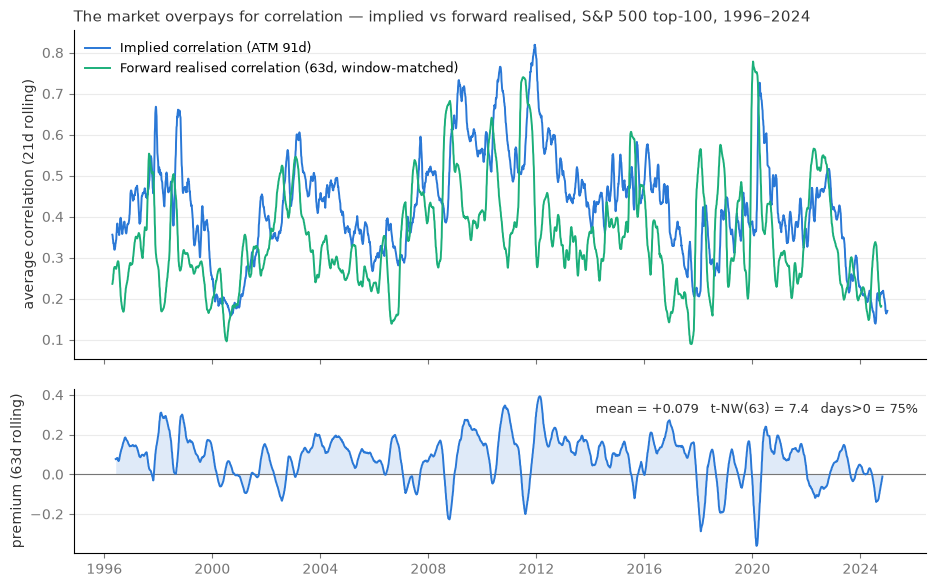

In [7]:
import matplotlib.pyplot as plt
import matplotlib.dates as mdates

C_IMP, C_FWD, INK, MUTED = "#2a78d6", "#1baf7a", "#333333", "#767676"

imp21 = sig["rho_implied"].rolling(21, min_periods=15).mean()
fwd21 = sig["rho_forward"].rolling(21, min_periods=15).mean()
prem63 = sig["premium"].rolling(63, min_periods=45).mean()
mu, t, n = nw_mean(sig["premium"])

fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(11, 6.8), sharex=True,
                               gridspec_kw={"height_ratios": [2, 1], "hspace": 0.12})

ax1.plot(imp21.index, imp21, color=C_IMP, lw=1.4, label="Implied correlation (ATM 91d)")
ax1.plot(fwd21.index, fwd21, color=C_FWD, lw=1.4, label="Forward realised correlation (63d, window-matched)")
ax1.set_ylabel("average correlation (21d rolling)", color=INK)
ax1.legend(loc="upper left", frameon=False, fontsize=9)
ax1.set_title("The market overpays for correlation — implied vs forward realised, S&P 500 top-100, 1996–2024",
              loc="left", fontsize=11, color=INK)

ax2.axhline(0, color=MUTED, lw=0.8)
ax2.plot(prem63.index, prem63, color=C_IMP, lw=1.4)
ax2.fill_between(prem63.index, 0, prem63, color=C_IMP, alpha=0.15, linewidth=0)
ax2.set_ylabel("premium (63d rolling)", color=INK)
ax2.annotate(f"mean = {mu:+.3f}   t-NW(63) = {t:.1f}   days>0 = {(sig['premium'].dropna()>0).mean():.0%}",
             xy=(0.99, 0.92), xycoords="axes fraction", ha="right", va="top",
             fontsize=9, color=INK)

for ax in (ax1, ax2):
    ax.spines[["top", "right"]].set_visible(False)
    ax.grid(axis="y", alpha=0.25)
    ax.tick_params(colors=MUTED)
ax2.xaxis.set_major_locator(mdates.YearLocator(4))

fig_dir = ROOT / "results" / "figures"
fig_dir.mkdir(parents=True, exist_ok=True)
fig.savefig(fig_dir / "fig_crp_validation.png", dpi=150, bbox_inches="tight")
plt.show()

## Findings & next step

To check in the outputs above:
1. $\rho_{\text{implied}} \in [0,1]$ everywhere (violations = 0 expected, consistent with the QA: basket IV > index IV every day);
2. premium **positive on average** with significant t-NW → the CRP exists over 1996–2024 (thesis validation);
3. signal also positive on average (the trailing proxy inherits the premium);
4. sub-periods: first glimpse of the S5 question (post-2003 compression?).

**Next step:** promotion into `src/dispersion/signal/implied_corr.py` + writing `signal.parquet`.